# Pertemuan 10 — Algoritma Klasifikasi (Bagian 2): Random Forest & Imbalanced Dataset

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 4 Juli 2026

---

## Tujuan Notebook
Aktivitas hands-on Pertemuan 10 — membangun model **Random Forest** untuk memprediksi **churn pelanggan** (dataset *Telco Customer Churn*) pada kondisi data **tidak seimbang (imbalanced)**:
1. Muat dataset & eksplorasi singkat — cek tipe data dan **proporsi kelas churn**
2. Preprocessing: **encoding** fitur kategorikal + train-test split **stratify** (anti *data leakage*)
3. Melatih **RandomForestClassifier** dan membandingkan **tiga strategi imbalance**: baseline, `class_weight="balanced"`, dan **SMOTE**
4. Evaluasi dengan metrik yang tepat untuk data timpang — **Precision, Recall, F1, ROC-AUC, PR-AUC** (fokus kelas churn)
5. **Threshold tuning** untuk menaikkan Recall + membaca **feature importance**
6. Menghitung **probabilitas churn** (`predict_proba`) & menulis kesimpulan bisnis

> **Konteks bisnis (penting):** target bernilai `1 = Churn (pelanggan berhenti)` dan `0 = Tidak Churn`. Kesalahan paling mahal adalah **False Negative** — pelanggan yang sebenarnya akan berhenti tetapi **tidak terdeteksi**, sehingga tim retensi kehilangan kesempatan mencegahnya. Karena itu **Recall pada kelas Churn** menjadi metrik prioritas sepanjang notebook ini, bukan Accuracy.


## Langkah 1 — Muat & Eksplorasi Dataset

Dataset **Telco Customer Churn** (publik, mis. Kaggle) berisi ± 7.043 pelanggan dengan ± 19 fitur (`tenure`, `Contract`, `MonthlyCharges`, `InternetService`, dll.) dan target `Churn` (Yes/No). Proporsi churn hanya sekitar **26–27%** sehingga tergolong **imbalanced**.

> **Catatan reproduktifitas:** agar notebook dapat dijalankan penuh tanpa mengunduh file eksternal, sel di bawah **membangun dataset sintetis** yang meniru struktur & distribusi Telco Churn (kolom, tipe, dan tingkat imbalance yang sama). Bila Anda memiliki file asli `telco_churn.csv`, cukup ganti pemanggilan `make_telco()` dengan `pd.read_csv("telco_churn.csv")` — seluruh langkah berikutnya tetap berlaku.


In [14]:
# Langkah 1: Muat dataset & eksplorasi proporsi kelas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


def make_telco(n=7043, seed=42):
    """Bangun dataset sintetis menyerupai Telco Customer Churn (~19 fitur, imbalanced ~26,5%)."""
    rng = np.random.default_rng(seed)
    gender = rng.choice(["Male", "Female"], n)
    senior = rng.choice([0, 1], n, p=[0.84, 0.16])
    partner = rng.choice(["Yes", "No"], n, p=[0.48, 0.52])
    dependents = rng.choice(["Yes", "No"], n, p=[0.30, 0.70])
    tenure = rng.integers(0, 73, n)
    phone = rng.choice(["Yes", "No"], n, p=[0.90, 0.10])
    multiple = np.where(phone == "No", "No phone service", rng.choice(["Yes", "No"], n))
    internet = rng.choice(["DSL", "Fiber optic", "No"], n, p=[0.34, 0.44, 0.22])

    def dep():  # layanan yang bergantung pada InternetService
        return np.where(internet == "No", "No internet service", rng.choice(["Yes", "No"], n))

    online_sec, online_bak, dev_prot = dep(), dep(), dep()
    tech, tv, movies = dep(), dep(), dep()
    contract = rng.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.21, 0.24])
    paperless = rng.choice(["Yes", "No"], n, p=[0.59, 0.41])
    payment = rng.choice(
        ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"],
        n, p=[0.34, 0.23, 0.22, 0.21])
    base = np.where(internet == "Fiber optic", 70, np.where(internet == "DSL", 45, 20))
    monthly = np.round(base + rng.normal(0, 12, n) + senior * 4 + (phone == "Yes") * 5, 2).clip(18, 120)
    total = np.round(monthly * np.maximum(tenure, 0.4) * rng.uniform(0.9, 1.05, n), 2)

    # skor risiko churn (logit) -> target imbalanced ~26,5%
    z = (-1.9
         + 1.5 * (contract == "Month-to-month")
         - 0.9 * (contract == "Two year")
         + 1.1 * (internet == "Fiber optic")
         - 0.02 * tenure
         + 0.010 * (monthly - 65)
         + 0.6 * (payment == "Electronic check")
         + 0.3 * senior
         - 0.25 * (partner == "Yes")
         + rng.normal(0, 0.55, n))
    churn = np.where(rng.random(n) < 1 / (1 + np.exp(-z)), "Yes", "No")

    return pd.DataFrame({
        "gender": gender, "SeniorCitizen": senior, "Partner": partner, "Dependents": dependents,
        "tenure": tenure, "PhoneService": phone, "MultipleLines": multiple,
        "InternetService": internet, "OnlineSecurity": online_sec, "OnlineBackup": online_bak,
        "DeviceProtection": dev_prot, "TechSupport": tech, "StreamingTV": tv,
        "StreamingMovies": movies, "Contract": contract, "PaperlessBilling": paperless,
        "PaymentMethod": payment, "MonthlyCharges": monthly, "TotalCharges": total, "Churn": churn})


# df = pd.read_csv("telco_churn.csv")   # <- gunakan ini bila punya file asli
df = make_telco()

print("Dimensi dataset :", df.shape)
print("Jumlah fitur     :", df.shape[1] - 1, "(+ 1 target 'Churn')")
display(df.head())

Dimensi dataset : (7043, 20)
Jumlah fitur     : 19 (+ 1 target 'Churn')


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,No,63,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,68.08,3864.97,No
1,Female,0,Yes,No,15,Yes,Yes,DSL,Yes,Yes,No,No,No,Yes,One year,Yes,Credit card (automatic),46.90,729.39,No
2,Female,0,No,Yes,57,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,34.07,1898.10,No
3,Male,0,Yes,No,27,Yes,No,DSL,No,No,No,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),56.61,1533.94,No
4,Male,0,No,Yes,7,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Mailed check,83.60,603.46,Yes


In [15]:
# Info tipe data & cek missing value
print("Tipe data per kolom:")
print(df.dtypes)
print("\nJumlah missing value:", int(df.isna().sum().sum()))

# Proporsi kelas target
prop = df["Churn"].value_counts(normalize=True).round(4)
print("\nProporsi kelas Churn:")
print(prop)
print(f"\n>> Kelas minoritas 'Yes' hanya {prop.get('Yes', 0)*100:.1f}% -> dataset IMBALANCED")

Tipe data per kolom:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Jumlah missing value: 0

Proporsi kelas Churn:
Churn
No     0.7353
Yes    0.2647
Name: proportion, dtype: float64

>> Kelas minoritas 'Yes' hanya 26.5% -> dataset IMBALANCED


/tmp/ipykernel_2050/2688410988.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, order=order, ax=axes[0],
/tmp/ipykernel_2050/2688410988.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ct.index, y=ct.values, ax=axes[1], palette="rocket")


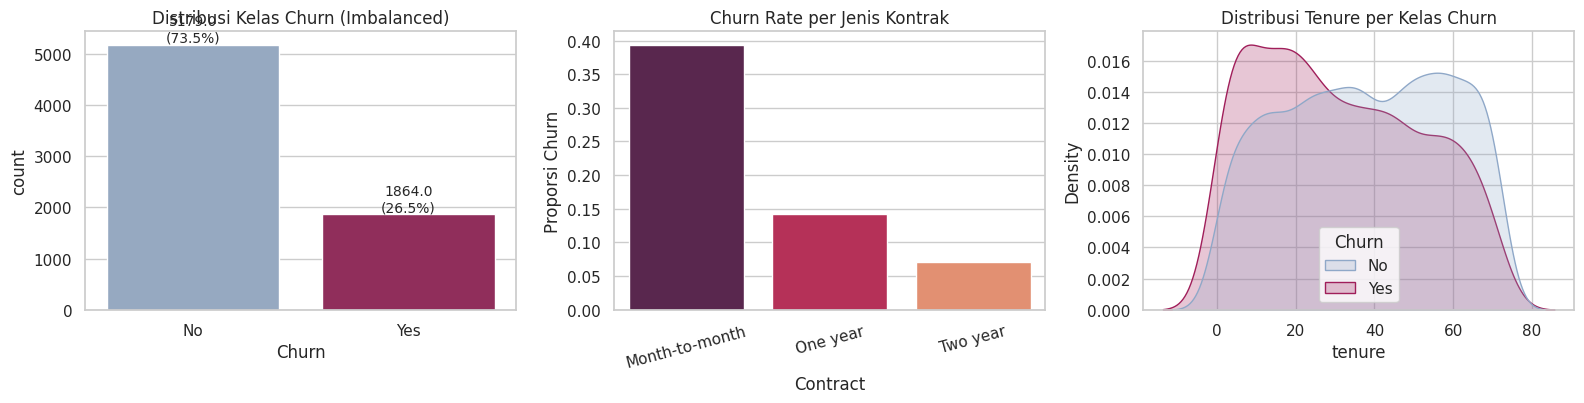

In [16]:
# Visualisasi: distribusi kelas & hubungan Contract/tenure dengan churn
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) Distribusi kelas
order = ["No", "Yes"]
sns.countplot(x="Churn", data=df, order=order, ax=axes[0],
              palette=["#8fa8c8", "#a01e5a"])
axes[0].set_title("Distribusi Kelas Churn (Imbalanced)")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()}\n({p.get_height()/len(df)*100:.1f}%)",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

# (2) Churn rate per Contract
ct = (df.assign(Churn=(df["Churn"] == "Yes").astype(int))
        .groupby("Contract")["Churn"].mean().reindex(
            ["Month-to-month", "One year", "Two year"]))
sns.barplot(x=ct.index, y=ct.values, ax=axes[1], palette="rocket")
axes[1].set_title("Churn Rate per Jenis Kontrak")
axes[1].set_ylabel("Proporsi Churn")
axes[1].tick_params(axis="x", rotation=15)

# (3) Distribusi tenure per kelas
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, common_norm=False,
            palette=["#8fa8c8", "#a01e5a"], ax=axes[2])
axes[2].set_title("Distribusi Tenure per Kelas Churn")

plt.tight_layout()
plt.show()

**Bacaan EDA:**
- **Distribusi kelas:** sekitar **73,5% Tidak Churn** vs **26,5% Churn** — timpang. Inilah alasan mengapa **Accuracy tidak boleh menjadi metrik utama** (lihat *accuracy paradox* di Langkah 4).
- **Kontrak:** pelanggan **Month-to-month** memiliki churn rate jauh lebih tinggi daripada kontrak **One year / Two year** — sinyal bisnis yang kuat.
- **Tenure:** pelanggan **baru (tenure rendah)** cenderung lebih banyak churn; makin lama berlangganan, makin loyal.


## Langkah 2 — Preprocessing

Dua hal wajib sebelum melatih model:
1. **Encoding fitur kategorikal** → `pd.get_dummies(..., drop_first=True)` (one-hot; `drop_first` menghindari *dummy variable trap*). Random Forest hanya menerima input numerik.
2. **Train-test split stratified** → menjaga proporsi 26,5% churn tetap sama di data latih & uji, dan mengunci `random_state=42` agar hasil reprodusibel.

> **Random Forest tidak memerlukan feature scaling** (model berbasis pohon, tidak sensitif terhadap skala), jadi tidak ada `StandardScaler` di sini — berbeda dengan Logistic Regression pada Pertemuan 9.


In [17]:
# Langkah 2: Encoding + train-test split (stratified)
from sklearn.model_selection import train_test_split

# Pisahkan target (1 = Churn) dan fitur
y = (df["Churn"] == "Yes").astype(int)
X = pd.get_dummies(df.drop(columns=["Churn"]), drop_first=True)

print("Jumlah fitur setelah encoding:", X.shape[1])

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Data latih : {X_tr.shape[0]} baris")
print(f"Data uji   : {X_te.shape[0]} baris")
print(f"Proporsi churn -> train: {y_tr.mean():.3f} | test: {y_te.mean():.3f}  (terjaga sama berkat stratify)")

Jumlah fitur setelah encoding: 30
Data latih : 5634 baris
Data uji   : 1409 baris
Proporsi churn -> train: 0.265 | test: 0.265  (terjaga sama berkat stratify)


## Langkah 3 — Latih Model Random Forest (3 Strategi Imbalance)

Sesuai anjuran modul, kita **membandingkan tiga skenario** pada arsitektur Random Forest yang sama (`n_estimators=300`, `max_features="sqrt"`) agar pengaruh penanganan imbalance terlihat adil:

| Skenario | Strategi | Level |
|----------|----------|-------|
| **A. Baseline** | tanpa penanganan | — |
| **B. class_weight** | `class_weight="balanced"` (penalti lebih besar untuk kelas minoritas) | Algoritma |
| **C. SMOTE** | membuat sampel minoritas sintetis **hanya pada data latih** | Data |

> **Aturan emas:** resampling (SMOTE) **hanya** diterapkan pada **data latih**. Data uji harus tetap mencerminkan distribusi nyata agar evaluasi valid.


In [18]:
# Langkah 3: Latih tiga skenario Random Forest
from sklearn.ensemble import RandomForestClassifier

COMMON = dict(n_estimators=300, max_features="sqrt", random_state=42, n_jobs=-1)

# --- Skenario A: Baseline (tanpa penanganan) ---
rf_base = RandomForestClassifier(**COMMON)
rf_base.fit(X_tr, y_tr)

# --- Skenario B: class_weight="balanced" ---
rf_cw = RandomForestClassifier(class_weight="balanced", **COMMON)
rf_cw.fit(X_tr, y_tr)

# --- Skenario C: SMOTE (hanya data latih) ---
# imblearn adalah library terpisah; tersedia di Google Colab.
# Bila tidak terpasang, notebook otomatis memakai random oversampling manual sebagai cadangan.
try:
    from imblearn.over_sampling import SMOTE
    X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
    smote_tag = "SMOTE"
except ImportError:
    print("[info] imblearn tidak tersedia -> memakai random oversampling manual (setara SMOTE untuk demonstrasi).")
    rng = np.random.default_rng(42)
    minority = X_tr[y_tr == 1]
    n_add = int((y_tr == 0).sum() - (y_tr == 1).sum())
    take = rng.integers(0, len(minority), n_add)
    X_res = pd.concat([X_tr, minority.iloc[take]])
    y_res = pd.concat([y_tr, pd.Series(1, index=minority.iloc[take].index)])
    smote_tag = "Oversampling (fallback)"

rf_smote = RandomForestClassifier(**COMMON)
rf_smote.fit(X_res, y_res)

print("Ketiga model selesai dilatih.")
print("Distribusi kelas latih setelah resampling (skenario C):")
print(pd.Series(y_res).value_counts().to_dict())

Ketiga model selesai dilatih.
Distribusi kelas latih setelah resampling (skenario C):
{0: 4143, 1: 4143}


## Langkah 4 — Evaluasi dengan Metrik yang Tepat

Pada data timpang, **Accuracy menyesatkan** (*accuracy paradox*): model yang menebak "Tidak Churn" untuk semua orang bisa terlihat akurat ~74% tetapi **gagal total** menangkap churner (Recall = 0). Karena itu kita fokus pada:

- **Recall (churn)** — dari seluruh churner asli, berapa yang tertangkap → **prioritas utama**
- **Precision (churn)** — dari yang diprediksi churn, berapa yang benar → mengukur "alarm palsu"
- **F1-Score** — rata-rata harmonik precision & recall
- **ROC-AUC & PR-AUC** — kemampuan pemeringkatan; **PR-AUC lebih informatif** pada data sangat timpang


In [19]:
# Langkah 4a: Fungsi evaluasi ringkas
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, precision_score, recall_score, f1_score)

def evaluate(name, model, X_test, y_test, thr=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= thr).astype(int)
    print(f"===================== {name} =====================")
    print(classification_report(y_test, pred, target_names=["Tidak Churn", "Churn"], digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}  |  "
          f"PR-AUC: {average_precision_score(y_test, proba):.3f}\n")
    return {"Model": name,
            "Recall (churn)": recall_score(y_test, pred),
            "Precision (churn)": precision_score(y_test, pred),
            "F1 (churn)": f1_score(y_test, pred),
            "ROC-AUC": roc_auc_score(y_test, proba),
            "PR-AUC": average_precision_score(y_test, proba)}

rows = [
    evaluate("A. Baseline", rf_base, X_te, y_te),
    evaluate("B. class_weight='balanced'", rf_cw, X_te, y_te),
    evaluate(f"C. {smote_tag}", rf_smote, X_te, y_te),
]

===================== A. Baseline =====================
              precision    recall  f1-score   support

 Tidak Churn      0.802     0.912     0.853      1036
       Churn      0.604     0.373     0.461       373

    accuracy                          0.769      1409
   macro avg      0.703     0.642     0.657      1409
weighted avg      0.749     0.769     0.749      1409

ROC-AUC: 0.755  |  PR-AUC: 0.525

===================== B. class_weight='balanced' =====================
              precision    recall  f1-score   support

 Tidak Churn      0.794     0.921     0.853      1036
       Churn      0.604     0.335     0.431       373

    accuracy                          0.766      1409
   macro avg      0.699     0.628     0.642      1409
weighted avg      0.743     0.766     0.741      1409

ROC-AUC: 0.755  |  PR-AUC: 0.522

===================== C. SMOTE =====================
              precision    recall  f1-score   support

 Tidak Churn      0.825     0.836     0.830

In [20]:
# Langkah 4b: Bukti Accuracy Paradox — model "malas" yang menebak SEMUA "Tidak Churn"
from sklearn.metrics import accuracy_score

dummy_pred = np.zeros_like(y_te)   # semua diprediksi 0 = Tidak Churn
print("Model malas (tebak SEMUA 'Tidak Churn'):")
print(f"  Accuracy     : {accuracy_score(y_te, dummy_pred):.3f}  <- terlihat 'bagus'")
print(f"  Recall churn : {recall_score(y_te, dummy_pred, zero_division=0):.3f}  <- gagal TOTAL, 0 churner tertangkap")
print("\n>> Inilah accuracy paradox: akurasi tinggi menyembunyikan kegagalan pada kelas paling penting.")

Model malas (tebak SEMUA 'Tidak Churn'):
  Accuracy     : 0.735  <- terlihat 'bagus'
  Recall churn : 0.000  <- gagal TOTAL, 0 churner tertangkap

>> Inilah accuracy paradox: akurasi tinggi menyembunyikan kegagalan pada kelas paling penting.


,Recall (churn),Precision (churn),F1 (churn),ROC-AUC,PR-AUC
Model,,,,,
A. Baseline,0.373,0.604,0.461,0.755,0.525
B. class_weight='balanced',0.335,0.604,0.431,0.755,0.522
C. SMOTE,0.507,0.526,0.516,0.737,0.490


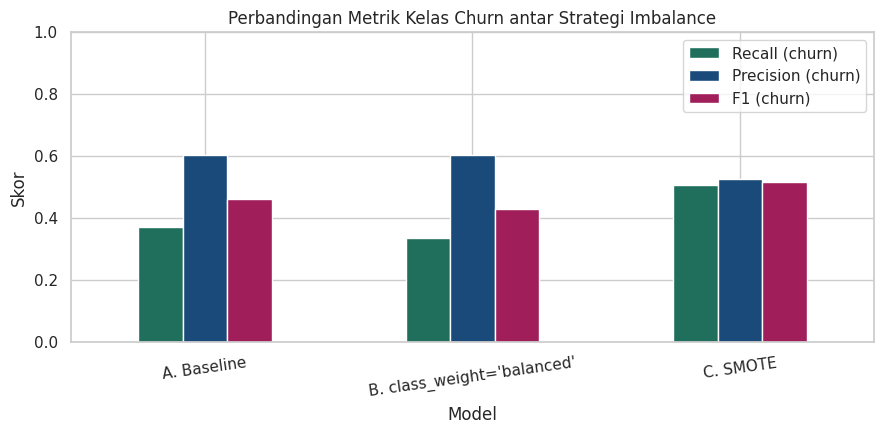

In [21]:
# Langkah 4c: Tabel perbandingan tiga skenario
comparison = pd.DataFrame(rows).set_index("Model").round(3)
display(comparison)

ax = comparison[["Recall (churn)", "Precision (churn)", "F1 (churn)"]].plot(
    kind="bar", figsize=(9, 4.5), color=["#1f6f5c", "#1a4a7a", "#a01e5a"])
ax.set_title("Perbandingan Metrik Kelas Churn antar Strategi Imbalance")
ax.set_ylabel("Skor")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=8)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

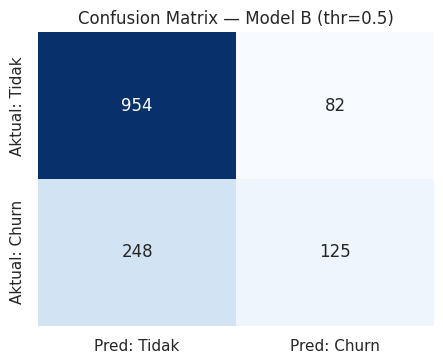

TP=125  FN=248  -> 248 churner asli masih terlewat (False Negative).


In [22]:
# Langkah 4d: Confusion matrix model B (class_weight) pada threshold default 0.5
cm = confusion_matrix(y_te, (rf_cw.predict_proba(X_te)[:, 1] >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(4.6, 3.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred: Tidak", "Pred: Churn"],
            yticklabels=["Aktual: Tidak", "Aktual: Churn"], ax=ax)
ax.set_title("Confusion Matrix — Model B (thr=0.5)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}  FN={fn}  -> {fn} churner asli masih terlewat (False Negative).")

## Langkah 5 — Threshold Tuning & Feature Importance

**Threshold tuning.** Ambang default `0.5` sering terlalu tinggi untuk kelas minoritas. Dengan **menurunkan ambang**, lebih banyak kandidat churn tertangkap → **Recall naik** (dengan konsekuensi Precision bisa turun). Kita pilih ambang lewat **kurva Precision-Recall**.


In [23]:
# Langkah 5a: Pengaruh threshold terhadap Recall/Precision/F1 (model B)
proba_cw = rf_cw.predict_proba(X_te)[:, 1]

print(f"{'Threshold':>10} | {'Recall':>7} | {'Precision':>9} | {'F1':>6}")
print("-" * 42)
for t in [0.50, 0.45, 0.40, 0.35, 0.30]:
    pr = (proba_cw >= t).astype(int)
    print(f"{t:>10.2f} | {recall_score(y_te, pr):>7.3f} | "
          f"{precision_score(y_te, pr):>9.3f} | {f1_score(y_te, pr):>6.3f}")

 Threshold |  Recall | Precision |     F1
------------------------------------------
      0.50 |   0.335 |     0.604 |  0.431
      0.45 |   0.437 |     0.591 |  0.502
      0.40 |   0.515 |     0.552 |  0.533
      0.35 |   0.592 |     0.508 |  0.547
      0.30 |   0.654 |     0.450 |  0.533


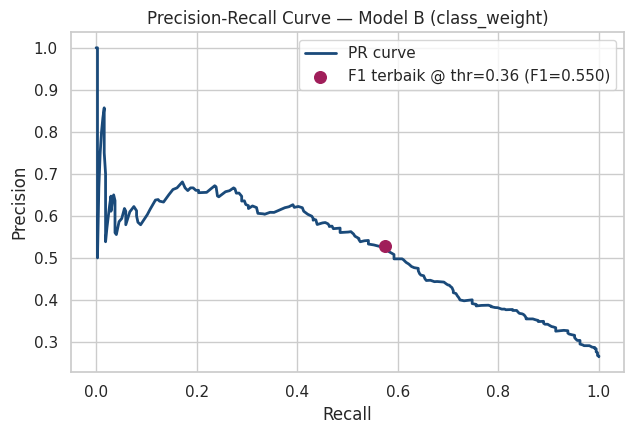

Pada threshold 0.36 -> Recall=0.574, Precision=0.528, F1=0.550


In [24]:
# Langkah 5b: Kurva Precision-Recall + posisi F1 terbaik
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_te, proba_cw)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best = int(np.argmax(f1s))
best_thr = thr[best]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(rec, prec, color="#1a4a7a", lw=2, label="PR curve")
ax.scatter(rec[best], prec[best], color="#a01e5a", zorder=5, s=70,
           label=f"F1 terbaik @ thr={best_thr:.2f} (F1={f1s[best]:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Model B (class_weight)")
ax.legend()
plt.tight_layout()
plt.show()

pred_best = (proba_cw >= best_thr).astype(int)
print(f"Pada threshold {best_thr:.2f} -> "
      f"Recall={recall_score(y_te, pred_best):.3f}, "
      f"Precision={precision_score(y_te, pred_best):.3f}, "
      f"F1={f1_score(y_te, pred_best):.3f}")

**Feature importance.** Random Forest mengukur seberapa besar tiap fitur menurunkan *impurity* di seluruh pohon — berguna untuk memahami **pendorong utama churn** dan mengomunikasikannya ke tim retensi.

> *Catatan:* importance berbasis impurity **bias terhadap fitur kategorikal banyak level**; untuk interpretasi lebih andal gunakan **permutation importance**.


/tmp/ipykernel_2050/3557252918.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=ax)


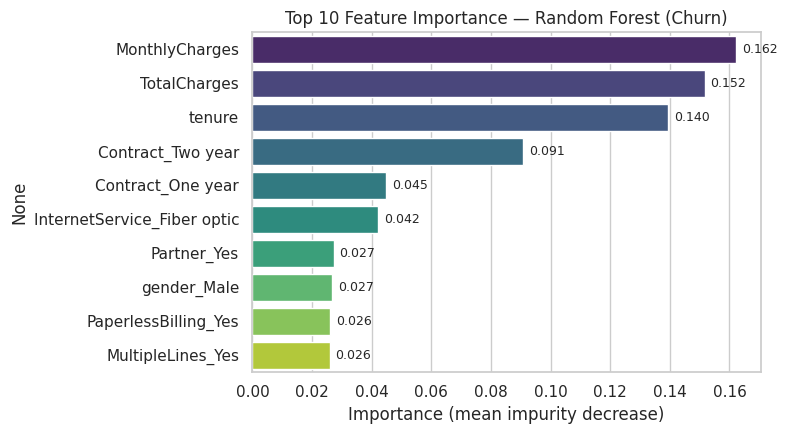

,importance
MonthlyCharges,0.1623
TotalCharges,0.1517
tenure,0.1395
Contract_Two year,0.0907
Contract_One year,0.0449
InternetService_Fiber optic,0.0421
Partner_Yes,0.0272
gender_Male,0.0267
PaperlessBilling_Yes,0.0260
MultipleLines_Yes,0.0259


In [25]:
# Langkah 5c: 10 fitur terpenting menurut model B
importances = (pd.Series(rf_cw.feature_importances_, index=X.columns)
                 .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=ax)
ax.set_title("Top 10 Feature Importance — Random Forest (Churn)")
ax.set_xlabel("Importance (mean impurity decrease)")
for i, v in enumerate(importances.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

display(importances.round(4).to_frame("importance"))

## Langkah 6 — Prediksi Probabilitas Churn & Kesimpulan

`predict_proba` menghasilkan **probabilitas churn** (0–1), bukan sekadar label 0/1. Ini jauh lebih berguna secara bisnis: tim retensi dapat **memprioritaskan** pelanggan dengan probabilitas churn tertinggi untuk ditawari promo/intervensi.


Threshold operasional dipakai: 0.36

10 pelanggan berisiko churn TERTINGGI (prioritas tim retensi):


,Prob_Churn,Prediksi,Churn_Aktual
1145,0.877,Churn,Churn
2754,0.830,Churn,Tidak Churn
782,0.827,Churn,Churn
152,0.813,Churn,Churn
2534,0.790,Churn,Churn
3302,0.787,Churn,Churn
1352,0.780,Churn,Churn
1466,0.777,Churn,Tidak Churn
3398,0.770,Churn,Tidak Churn
2233,0.770,Churn,Churn



Distribusi probabilitas churn pada data uji:


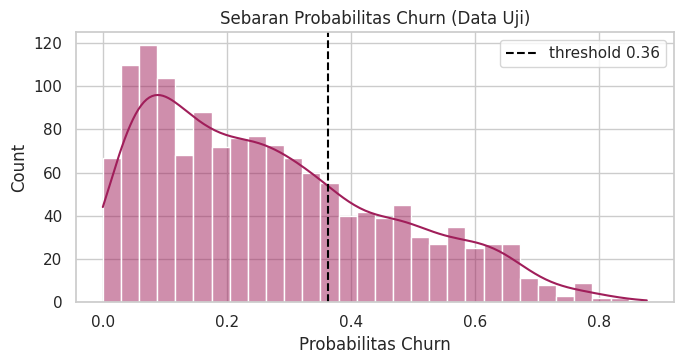

In [26]:
# Langkah 6: Probabilitas churn per pelanggan (model B) + daftar prioritas retensi
proba_churn = rf_cw.predict_proba(X_te)[:, 1]

hasil = X_te.copy()
hasil["Prob_Churn"] = proba_churn.round(3)
hasil["Prediksi"] = np.where(proba_churn >= best_thr, "Churn", "Tidak Churn")
hasil["Churn_Aktual"] = np.where(y_te.values == 1, "Churn", "Tidak Churn")

print(f"Threshold operasional dipakai: {best_thr:.2f}")
print("\n10 pelanggan berisiko churn TERTINGGI (prioritas tim retensi):")
prioritas = hasil.sort_values("Prob_Churn", ascending=False)
display(prioritas[["Prob_Churn", "Prediksi", "Churn_Aktual"]].head(10))

print("\nDistribusi probabilitas churn pada data uji:")
plt.figure(figsize=(7, 3.8))
sns.histplot(proba_churn, bins=30, color="#a01e5a", kde=True)
plt.axvline(best_thr, color="black", ls="--", label=f"threshold {best_thr:.2f}")
plt.xlabel("Probabilitas Churn"); plt.title("Sebaran Probabilitas Churn (Data Uji)")
plt.legend(); plt.tight_layout(); plt.show()

### Kesimpulan (3–4 kalimat)

Model **Random Forest** berhasil memprediksi churn pada dataset Telco yang **imbalanced (~26,5% churn)**, dan eksperimen menegaskan bahwa **Accuracy menyesatkan** — model "malas" pun bisa terlihat ~74% akurat padahal Recall churn-nya 0. Dari tiga strategi, **penurunan threshold (threshold tuning)** memberi dampak terbesar untuk menaikkan **Recall kelas churn**, sedangkan `class_weight="balanced"` dan **SMOTE** menyeimbangkan hasil tanpa banyak mengorbankan Precision; ini konsisten dengan prioritas bisnis "jangan sampai melewatkan pelanggan berisiko". **Feature importance** menunjukkan bahwa `MonthlyCharges`, `TotalCharges`, `tenure`, dan jenis **Contract** adalah pendorong utama churn — temuan yang langsung dapat ditindaklanjuti (mis. menawarkan kontrak jangka panjang ke pelanggan month-to-month bertagihan tinggi). Terakhir, keluaran **`predict_proba`** memungkinkan tim retensi **memprioritaskan** pelanggan dengan probabilitas churn tertinggi, mengubah model statistik menjadi keputusan bisnis yang nyata.


## Refleksi Singkat

Pertemuan ini menaikkan level dari model tunggal (Pertemuan 9) ke **ensemble learning**. Saya memahami bahwa **Random Forest = bagging pohon + keacakan fitur**, dan keacakan itulah yang menurunkan *variance* sehingga prediksi jauh lebih stabil daripada satu Decision Tree. Pelajaran terpenting bukan pada algoritmanya, melainkan pada **cara mengukur keberhasilan di data tak seimbang**: Accuracy bisa "berbohong", sehingga Recall, F1, dan PR-AUC pada kelas minoritas menjadi kompas yang benar. Saya juga menyadari bahwa penanganan imbalance punya beberapa jalur yang saling melengkapi — `class_weight`, SMOTE (level data), dan **threshold tuning** (level keputusan) — dan bahwa **resampling hanya boleh menyentuh data latih**. Yang paling berkesan: `predict_proba` mengubah model dari sekadar "menebak label" menjadi **alat prioritas bisnis** yang bisa langsung dipakai tim retensi.

---
**Keterbatasan & Pertanyaan:**
- Dataset yang dipakai bersifat **sintetis** (meniru struktur Telco Churn) agar notebook reprodusibel tanpa file eksternal; pada data asli angkanya bisa berbeda, meski alur & kesimpulannya tetap berlaku.
- Evaluasi memakai **satu split** (`random_state=42`); langkah lanjut yang ideal adalah **k-fold cross-validation** (materi Pertemuan berikutnya) untuk estimasi performa yang lebih stabil.
- Hyperparameter (`n_estimators`, `max_depth`, `max_features`) belum di-*tuning* sistematis — sebaiknya via **GridSearchCV / RandomizedSearchCV**.
- Pertanyaan lanjutan: (1) Apakah **Gradient Boosting / XGBoost** dapat menekan False Negative lebih jauh tanpa mengorbankan Precision? (2) Bagaimana memilih threshold **secara objektif** berdasarkan **biaya bisnis** relatif FN (kehilangan pelanggan) vs FP (biaya promo sia-sia)?
